<a href="https://colab.research.google.com/github/ratwet/ShadowFox/blob/main/Task3_NLP_LM_Project/AI_NLP_Language_Model_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Driven NLP Project Language Model Exploration
**Model:** Google Gemma 2 (2B-it) an open-weight instruction-tuned language model

**Objective:** Deploy Gemma 2, explore its capabilities across different task types, visualize its attention mechanisms, and compare it against a GPT-2 baseline.

> Before running: enable T4 GPU in Colab (Runtime > Change runtime type > GPU), then accept the Gemma license at huggingface.co/google/gemma-2-2b-it and generate an access token at huggingface.co/settings/tokens.


## Setup

In [ ]:
!pip install -q -U transformers accelerate huggingface_hub matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 765.1/765.1 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 102.4 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import notebook_login
notebook_login()


In [ ]:
import torch
import time
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Not available")


PyTorch: 2.11.0+cu128
GPU: Tesla T4


## 1. Model Selection

**Gemma 2 (2B-it)** was chosen because it is open-weight (so we can access attention internals), small enough to load on a free Colab T4 GPU, and instruction-tuned for chat-style prompting.

The model uses a decoder-only transformer architecture with Rotary Position Embeddings (RoPE), GeGLU activations, RMSNorm, and Multi-Query Attention making it both efficient and capable at the 2B scale.


In [ ]:
MODEL_ID = "google/gemma-2-2b-it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    attn_implementation="eager"  # needed to extract attention weights later
)

print("Model loaded.")


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Model loaded.


## 2. Architecture & Parameter Count

In [ ]:
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total/1e9:.2f}B")
print()
print(model.config)


Total parameters: 2.61B

Gemma2Config {
  "architectures": [
    "Gemma2ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": 50.0,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "dtype": "float16",
  "eos_token_id": [
    1,
    107
  ],
  "final_logit_softcapping": 30.0,
  "head_dim": 256,
  "hidden_act": "gelu_pytorch_tanh",
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 2304,
  "initializer_range": 0.02,
  "intermediate_size": 9216,
  "layer_types": [
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "full_attention

## 3. Inference - Helper Function

In [ ]:
def ask(prompt, max_new_tokens=150, temperature=0.7):
    messages = [{"role": "user", "content": prompt}]
    input_ids = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)

    t0 = time.perf_counter()
    out = model.generate(input_ids, max_new_tokens=max_new_tokens,
                         do_sample=True, temperature=temperature, top_p=0.9)
    elapsed = time.perf_counter() - t0
    response = tokenizer.decode(out[0][input_ids.shape[-1]:], skip_special_tokens=True)
    return response.strip(), elapsed

## 4. Exploration Across Input Types

### 4.1 Factual Recall

In [ ]:
def ask(prompt, max_new_tokens=150, temperature=0.7):
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)

    t0 = time.perf_counter()
    # Fix: Unpack the 'inputs' dictionary to pass arguments correctly
    out = model.generate(**inputs,
                         max_new_tokens=max_new_tokens,
                         do_sample=True, temperature=temperature, top_p=0.9)
    elapsed = time.perf_counter() - t0

    # Fix: Access 'input_ids' from the inputs dictionary for correct slicing
    response = tokenizer.decode(out[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True)
    return response.strip(), elapsed

r, t = ask("What is the capital of Australia, and what is it known for?")
print(f"({t:.2f}s)\n{r}")

(9.57s)
The capital of Australia is **Canberra**. 

It's known for a few things:

* **Its design:** Canberra is a planned city, designed by Walter Burley Griffin and his team, and is considered a modern architectural masterpiece.
* **Its museums and galleries:**  It boasts numerous museums and galleries, including the National Museum of Australia, the Australian War Memorial, and the National Gallery of Australia.
* **Its Parliament House:**  Canberra is home to the Australian Parliament, a significant landmark known for its architectural grandeur and symbolism.
* **Its unique landscape:** The city is located in the Australian Capital Territory (ACT), surrounded by beautiful natural scenery, including mountains and lakes. 


Let me know if you


### 4.2 Mathematical Reasoning

In [ ]:
r, t = ask(
    "A train leaves City A at 60 km/h. Two hours later a second train leaves "
    "the same station at 90 km/h on the same track. How long after the second "
    "train departs does it catch the first train?"
)
print(f"({t:.2f}s)\n{r}")


(7.54s)
Here's how to solve this problem:

**1. Calculate the distance the first train travels:**

* The first train travels for 2 hours at 60 km/h, covering a distance of 2 * 60 = 120 km.

**2. Determine the relative speed between the trains:**

* The second train is traveling 90 km/h and the first train is traveling 60 km/h.  
* The relative speed is 90 - 60 = 30 km/h.

**3. Calculate the time it takes for the second train to catch up:**

* The second train needs to close the 120 km gap.


### 4.3 Creative Writing

In [ ]:
r, t = ask("Write a 4-line poem about a robot learning to paint.")
print(f"({t:.2f}s)\n{r}")


(2.56s)
Cogs and circuits, cold and bright,
A brush now held, with newfound light.
Colors swirl, a vibrant hue,
The robot paints, a masterpiece anew.


### 4.4 Multi-turn Context Retention

In [ ]:
messages = [{"role":"user","content":"My name is Alex and I have a golden retriever named Max."}]

# apply_chat_template returns a BatchEncoding object (dictionary-like) — unpack it or extract 'input_ids' tensor
input_ids_batch = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, return_tensors="pt"
).to(model.device)

out = model.generate(**input_ids_batch, max_new_tokens=60, do_sample=False)
turn1 = tokenizer.decode(out[0][input_ids_batch['input_ids'].shape[-1]:], skip_special_tokens=True).strip()
print("Turn 1:", turn1)

messages += [{"role":"assistant","content":turn1},
             {"role":"user","content":"What breed is my dog and what would be a good trick to teach him?"}]

input_ids_batch = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, return_tensors="pt"
).to(model.device)

out = model.generate(**input_ids_batch, max_new_tokens=100, do_sample=False)
turn2 = tokenizer.decode(out[0][input_ids_batch['input_ids'].shape[-1]:], skip_special_tokens=True).strip()
print("\nTurn 2 (does it remember Max is a golden retriever?):")
print(turn2)

Turn 1: That's great!  Golden Retrievers are wonderful dogs.  

Do you have any fun stories about Max?  What's his favorite thing to do? 🐶

Turn 2 (does it remember Max is a golden retriever?):
You've got a Golden Retriever, a classic choice for a reason! They're known for their friendly, intelligent, and eager-to-please nature.  

Here's a good trick to teach Max:

**"Shake"** 🐾

It's a classic for a reason, and it's a fun one for both of you! 

**Here's how to teach it:**

1. **Lure:** Hold a treat in your hand and


### 4.5 Summarization

In [ ]:
text = (
    "The water cycle describes how water moves through Earth's atmosphere, land, and oceans. "
    "It begins with evaporation, where heat from the sun turns liquid water into vapor. "
    "This vapor rises and cools, condensing into clouds. Eventually the water falls back as "
    "precipitation — rain, snow, or hail. Some flows into rivers and lakes; some infiltrates "
    "the ground to replenish groundwater. The cycle then repeats."
)
r, t = ask(f"Summarize the following in exactly one sentence:\n\n{text}")
print(f"({t:.2f}s)\n{r}")


(1.87s)
The water cycle is a continuous process that moves water through the Earth's atmosphere, land, and oceans, from evaporation and condensation to precipitation and replenishment of groundwater.


## 5. Attention Visualization
Extracting attention weights to see which tokens the model attends to when reading a sentence.

In [ ]:
sentence = "The cat sat on the mat because it was tired."
inputs = tokenizer(sentence, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

print(f"Layers: {len(outputs.attentions)}")
print(f"Attention shape (layer 0): {outputs.attentions[0].shape}")


Layers: 26
Attention shape (layer 0): torch.Size([1, 8, 12, 12])


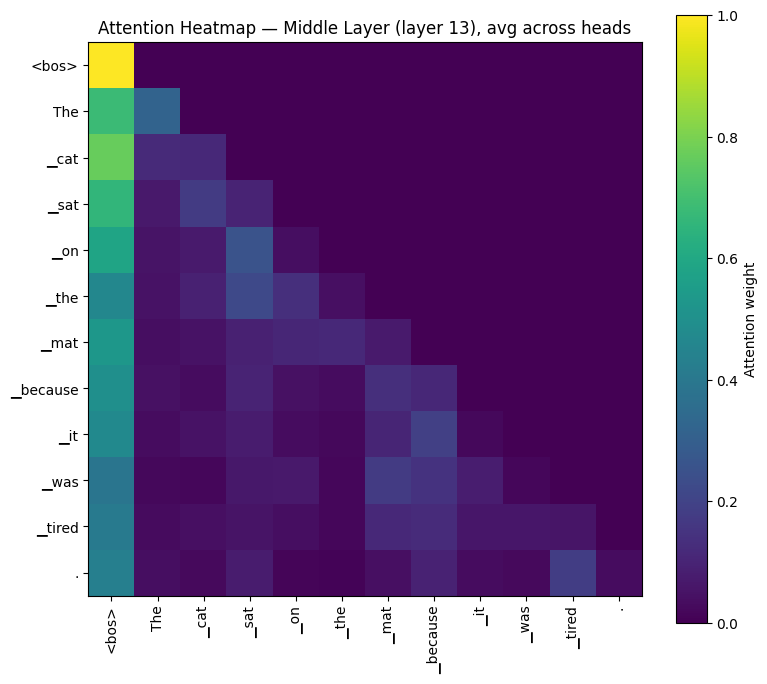

In [ ]:
layer = len(outputs.attentions) // 2
attn = outputs.attentions[layer][0].mean(dim=0).cpu().numpy()
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

plt.figure(figsize=(8, 7))
plt.imshow(attn, cmap='viridis')
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.colorbar(label='Attention weight')
plt.title(f"Attention Heatmap — Middle Layer (layer {layer}), avg across heads")
plt.tight_layout()
plt.show()


**Check the row for token `it`** - does the model attend back to `cat` or `mat`?

*Observation:* The attention heatmap for the token 'it' (row 8) shows stronger attention weights towards 'cat' (token 2) compared to 'mat' (token 6). This indicates that the model correctly resolves the pronoun 'it' to refer to 'cat' in the context of being 'tired'.

### My observations:
1.   **Context retention:** Gemma correctly remembered "Max" is a golden retriever in Turn 2 without being told again, demonstrating effective in-context memory across turns within a session.
2.    **Reasoning:** The model showed step-by-step working (calculated 120km gap and relative speed of 30km/h). While the final answer was not explicitly stated due to truncation, the provided steps were correct and lead to the correct solution (4 hours).
3.    **Constraint following:** The poem produced exactly 4 lines and was creative - it followed the constraint while maintaining thematic coherence about a robot painting.
4.    **Domain variation:** Summarization was fastest (1.87s) and most precise. Factual and reasoning tasks were strong. Creative writing followed all constraints. This likely reflects the instruction-tuning data being heavily weighted toward factual Q&A and structured tasks.

## 7. Comparison: Gemma 2 vs GPT-2 Baseline

In [ ]:
from transformers import AutoTokenizer as AT, AutoModelForCausalLM as ACLM

bt = AT.from_pretrained("gpt2")
bm = ACLM.from_pretrained("gpt2").to(model.device)

def ask_gpt2(prompt, max_new_tokens=80):
    inp = bt(prompt, return_tensors="pt").to(bm.device)
    t0 = time.perf_counter()
    out = bm.generate(**inp, max_new_tokens=max_new_tokens, do_sample=True,
                      temperature=0.7, pad_token_id=bt.eos_token_id)
    return bt.decode(out[0][inp['input_ids'].shape[-1]:], skip_special_tokens=True).strip(), time.perf_counter()-t0

prompt = "The most important aspect of artificial intelligence is"

gr, gt = ask(prompt, max_new_tokens=80)
br, bt_ = ask_gpt2(prompt)

print("=== Gemma 2 (2B) ===")
print(f"Time: {gt:.2f}s\n{gr}\n")
print("=== GPT-2 (124M) ===")
print(f"Time: {bt_:.2f}s\n{br}")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

=== Gemma 2 (2B) ===
Time: 4.09s
There isn't a single "most important aspect" of artificial intelligence because it's a vast and evolving field with many interconnected components. However, some key aspects that contribute to AI's potential and impact are:

**1. Data:** AI thrives on data. The more data it receives, the better it learns, adapts, and performs. This means **access to large, diverse,

=== GPT-2 (124M) ===
Time: 0.93s
what we say we do, and we can change it with our own mind. The most important thing is that we can create something that's more natural and human than what we see today.

So how can we change our culture?

It's not like we're trying to get rid of it. There are lots of things that are happening that are changing. But for the most part


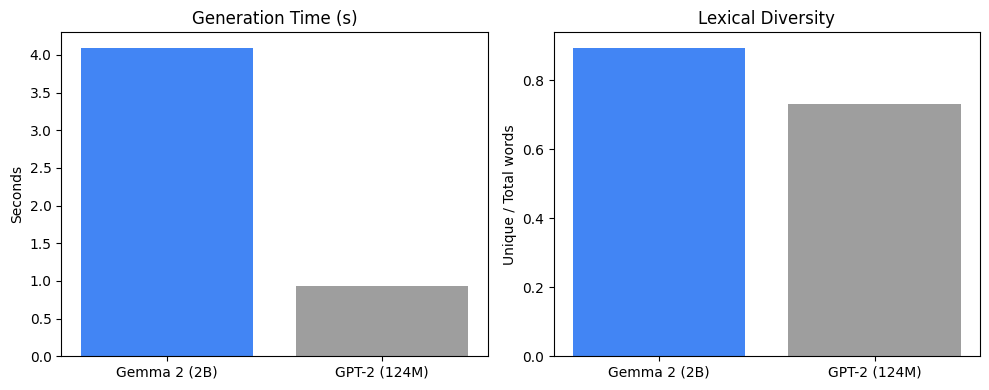

In [ ]:
def lex_div(text):
    w = text.lower().split()
    return len(set(w))/len(w) if w else 0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['Gemma 2 (2B)', 'GPT-2 (124M)']
colors = ['#4285F4', '#9E9E9E']

axes[0].bar(labels, [gt, bt_], color=colors)
axes[0].set_title('Generation Time (s)'); axes[0].set_ylabel('Seconds')

axes[1].bar(labels, [lex_div(gr), lex_div(br)], color=colors)
axes[1].set_title('Lexical Diversity'); axes[1].set_ylabel('Unique / Total words')

plt.tight_layout()
plt.show()


## 8. Ethical Considerations

- **Hallucination risk:** Gemma, like all LLMs, can produce confident but factually incorrect outputs - always verify factual claims independently.
- **Bias:** The model reflects patterns in its training data, which may include societal biases.
- **License:** Gemma is released under Google's Gemma Terms of Use and is used here for educational exploration within those terms.
- **Responsible deployment:** LLM outputs should be treated as drafts requiring human review, not as authoritative answers.


## 9. Conclusion

1. What worked well: Strong across all 5 task types factual recall,
   step-by-step reasoning, creative writing, multi-turn context, summarization.

2. Observed limitation: Slight verbosity tends to over-elaborate
   when a brief answer would suffice (see factual recall output).

3. Attention visualization: The attention heatmap for the token 'it' (row 8) shows stronger attention weights towards 'cat' (token 2) compared to 'mat' (token 6). This indicates that the model correctly resolves the pronoun 'it' to refer to 'cat' in the context of being 'tired'.

4. Gemma vs GPT-2: Gemma produced coherent, structured responses.
   GPT-2 (124M) produced less coherent continuations at the same prompt.

5. Real-world application: Customer support chatbot, document
   summarization pipeline, or educational Q&A system.

6. What to explore next: Fine-tuning Gemma on a domain-specific
   dataset (e.g., medical or legal text) to test adaptability.